# SMS Spam Filter – DLBDSME01 Model Engineering, Task 3

This notebook follows the CRISP-DM phases:
1. Business understanding
2. Data understanding
3. Data preparation
4. Modelling
5. Evaluation
6. Deployment (integration concept)

All figures, tables and metrics used in the case study are generated by this notebook.

In [1]:
# 0. Setup: imports, paths, logging and reproducibility settings
import hashlib
import logging
import platform
import sys
from pathlib import Path

import matplotlib
import numpy as np
import pandas as pd
import sklearn

# --- Reproducibility --------------------------------------------------------
RANDOM_STATE = 42  # single seed used for every split and model in this notebook

# --- Project paths ----------------------------------------------------------
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":  # VS Code runs the notebook from its own folder
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_FILE = PROJECT_ROOT / "data" / "raw" / "SMSSpamCollection.csv"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"
LOGS_DIR = PROJECT_ROOT / "results" / "logs"

for folder in (FIGURES_DIR, TABLES_DIR, LOGS_DIR):
    folder.mkdir(parents=True, exist_ok=True)

# --- Logging (screen + file) ------------------------------------------------
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
    handlers=[
        logging.StreamHandler(sys.stdout),
        logging.FileHandler(LOGS_DIR / "notebook_run.log", mode="w", encoding="utf-8"),
    ],
    force=True,  # replace any handlers Jupyter created earlier
)
logger = logging.getLogger("spam_filter")

# --- Environment check ------------------------------------------------------
logger.info("Python       %s", platform.python_version())
logger.info("Interpreter  %s", sys.executable)
logger.info("numpy        %s", np.__version__)
logger.info("pandas       %s", pd.__version__)
logger.info("scikit-learn %s", sklearn.__version__)
logger.info("matplotlib   %s", matplotlib.__version__)
logger.info("Project root %s", PROJECT_ROOT)

# --- Raw data check ---------------------------------------------------------
if not DATA_FILE.exists():
    raise FileNotFoundError(f"Raw data file not found: {DATA_FILE}")

sha256 = hashlib.sha256(DATA_FILE.read_bytes()).hexdigest()
logger.info("Raw data     %s (%d bytes)", DATA_FILE.name, DATA_FILE.stat().st_size)
logger.info("SHA-256      %s", sha256)

2026-09-17 15:16:43 | INFO | Python       3.12.3
2026-09-17 15:16:43 | INFO | Interpreter  C:\AAAsantiago\IU Data Science\Semestres\6 Sexto semestre\Model Engineering\Code\IU_Model_Engineering\.venv\Scripts\python.exe
2026-09-17 15:16:43 | INFO | numpy        2.5.3
2026-09-17 15:16:43 | INFO | pandas       3.0.5
2026-09-17 15:16:43 | INFO | scikit-learn 1.9.1
2026-09-17 15:16:43 | INFO | matplotlib   3.11.2
2026-09-17 15:16:43 | INFO | Project root C:\AAAsantiago\IU Data Science\Semestres\6 Sexto semestre\Model Engineering\Code\IU_Model_Engineering
2026-09-17 15:16:43 | INFO | Raw data     SMSSpamCollection.csv (477907 bytes)
2026-09-17 15:16:43 | INFO | SHA-256      7d039a24a6083ed9ef0f806ebad56bbb976e3aeb8de05669173bfdc4996c239d


## 1. Business understanding

**Situation:** The company is opening a public short-message channel for customer feedback. Open channels attract spam.

**Goal:** A binary classification model that labels incoming short messages as spam or ham (legitimate).

**Service-team requirements (Task 3):**
- The filter is adjustable through spam-risk levels, from "low-risk" (very restrictive) to "high-risk" (not restrictive).
- Messages that pass the "low-risk" level are displayed immediately; all other messages are moved to a folder for further analysis.
- A strategy for handling that folder is needed so that legitimate customer messages are not lost.

**Implication for evaluation:** The two error types have different business consequences. A legitimate message classified as spam delays or loses customer feedback. A spam message classified as legitimate is displayed on the channel. The evaluation therefore reports both error types, not only overall accuracy.

## 2. Data understanding

### 2.1 Load the raw data and verify its structure

Loading decisions:
- The file is tab-separated and has no header row.
- Some messages contain quotation marks that belong to the text, so quote handling is switched off (`csv.QUOTE_NONE`).
- All values are read as text, and no text is converted into a missing value.

Checks: the number of loaded rows must equal the number of lines in the file, and the label counts must match the dataset documentation.

In [2]:
# 2.1 Load the raw data and verify its structure
import csv

COLUMN_NAMES = ["label", "message"]

# Message counts documented in the dataset description (Additional Information, section 3.3)
DOCUMENTED_COUNTS = {
    "ham": 450 + 3375 + 1002,  # Tagg PhD thesis + NUS SMS Corpus + SMS Spam Corpus v.0.1 Big
    "spam": 425 + 322,         # Grumbletext + SMS Spam Corpus v.0.1 Big
}

# --- Count non-empty lines in the raw file (one line = one message) ---------
with DATA_FILE.open(encoding="utf-8") as file:
    n_lines = sum(1 for line in file if line.strip())
logger.info("Non-empty lines in raw file: %d", n_lines)

# --- Load with explicit settings --------------------------------------------
sms_raw = pd.read_csv(
    DATA_FILE,
    sep="\t",                # tab-separated, despite the .csv extension
    header=None,             # no header row in the file
    names=COLUMN_NAMES,
    quoting=csv.QUOTE_NONE,  # quotation marks belong to the message text
    dtype=str,               # read everything as text
    keep_default_na=False,   # keep texts such as "NA" instead of turning them into missing values
    encoding="utf-8",
)
logger.info("Loaded with explicit settings: %d rows, %d columns", *sms_raw.shape)

# --- Comparison: what default quote handling would do -----------------------
sms_default = pd.read_csv(DATA_FILE, sep="\t", header=None, names=COLUMN_NAMES)
n_merged_rows = int(sms_default["message"].str.contains("\n", regex=False).sum())
logger.info(
    "Loaded with default quote handling: %d rows (%d messages lost, %d row(s) with merged lines)",
    len(sms_default), len(sms_raw) - len(sms_default), n_merged_rows,
)
del sms_default  # only needed for this comparison

# --- Structural checks ------------------------------------------------------
if len(sms_raw) != n_lines:
    raise ValueError(f"Row count {len(sms_raw)} does not match line count {n_lines}")

invalid_labels = set(sms_raw["label"]) - set(DOCUMENTED_COUNTS)
if invalid_labels:
    raise ValueError(f"Unexpected label values: {invalid_labels}")

label_counts = sms_raw["label"].value_counts()
for label, documented in DOCUMENTED_COUNTS.items():
    actual = int(label_counts[label])
    share = 100 * actual / len(sms_raw)
    logger.info("%-4s: %d messages (%.1f%%) | documented: %d", label, actual, share, documented)
    if actual != documented:
        raise ValueError(f"'{label}' count {actual} differs from documented {documented}")

logger.info("Structural checks passed: row count, label values and label counts match")
sms_raw.head()

2026-09-17 15:16:44 | INFO | Non-empty lines in raw file: 5574
2026-09-17 15:16:44 | INFO | Loaded with explicit settings: 5574 rows, 2 columns
2026-09-17 15:16:44 | INFO | Loaded with default quote handling: 5572 rows (2 messages lost, 1 row(s) with merged lines)
2026-09-17 15:16:44 | INFO | ham : 4827 messages (86.6%) | documented: 4827
2026-09-17 15:16:44 | INFO | spam: 747 messages (13.4%) | documented: 747
2026-09-17 15:16:44 | INFO | Structural checks passed: row count, label values and label counts match


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### 2.2 Data quality assessment

Each check counts the affected messages per class. Nothing is changed here; handling decisions follow in Data preparation.

- **Completeness:** empty messages
- **Uniqueness:** repeated messages
- **Consistency:** identical texts with different labels
- **Formatting and encoding:** whitespace, HTML escapes, placeholders, faulty characters

In [3]:
# 2.2 Data quality assessment (no data are changed here)
messages = sms_raw["message"]
n_per_label = sms_raw["label"].value_counts()


def count_flagged(dimension: str, check: str, flagged: pd.Series) -> dict:
    """Count flagged messages per label and as a share of each label."""
    counts = sms_raw.loc[flagged, "label"].value_counts()
    ham, spam = int(counts.get("ham", 0)), int(counts.get("spam", 0))
    return {
        "Dimension": dimension,
        "Check": check,
        "Ham": ham,
        "Spam": spam,
        "Total": ham + spam,
        "% of ham": round(100 * ham / n_per_label["ham"], 1),
        "% of spam": round(100 * spam / n_per_label["spam"], 1),
    }


quality_checks = [
    count_flagged("Completeness", "Empty or whitespace-only message",
                  messages.str.strip() == ""),
    count_flagged("Uniqueness", "Duplicate of an earlier message (same label and text)",
                  sms_raw.duplicated()),
    count_flagged("Consistency", "Same text with conflicting labels",
                  sms_raw.groupby("message")["label"].transform("nunique") > 1),
    count_flagged("Formatting", "Leading or trailing whitespace",
                  messages != messages.str.strip()),
    count_flagged("Formatting", "HTML-escaped characters (&lt; &gt; &amp;)",
                  messages.str.contains(r"&(?:lt|gt|amp);", regex=True)),
    count_flagged("Formatting", "Placeholder instead of original content (e.g. &lt;#&gt;, &lt;TIME&gt;)",
                  messages.str.contains(r"&lt;(?:#|[A-Z]+)&gt;", regex=True)),
    count_flagged("Encoding", "Windows control character instead of punctuation (e.g. \\x92)",
                  messages.str.contains(r"[\x80-\x9f]", regex=True)),
]
quality_table = pd.DataFrame(quality_checks)
quality_table.to_csv(TABLES_DIR / "tab_data_quality.csv", index=False)

# --- Class balance before and after removing duplicates ---------------------
unique_counts = sms_raw.drop_duplicates()["label"].value_counts()
logger.info("All messages:    ham %d, spam %d (spam share %.1f%%)",
            n_per_label["ham"], n_per_label["spam"], 100 * n_per_label["spam"] / len(sms_raw))
logger.info("Unique messages: ham %d, spam %d (spam share %.1f%%)",
            unique_counts["ham"], unique_counts["spam"], 100 * unique_counts["spam"] / unique_counts.sum())
logger.info("Saved %s", "tab_data_quality.csv")
quality_table

2026-09-17 15:19:38 | INFO | All messages:    ham 4827, spam 747 (spam share 13.4%)
2026-09-17 15:19:38 | INFO | Unique messages: ham 4518, spam 653 (spam share 12.6%)
2026-09-17 15:19:38 | INFO | Saved tab_data_quality.csv


,Dimension,Check,Ham,Spam,Total,% of ham,% of spam
0,Completeness,Empty or whitespace-only message,0,0,0,0.0,0.0
1,Uniqueness,Duplicate of an earlier message (same label an...,309,94,403,6.4,12.6
2,Consistency,Same text with conflicting labels,0,0,0,0.0,0.0
3,Formatting,Leading or trailing whitespace,156,31,187,3.2,4.1
4,Formatting,HTML-escaped characters (&lt; &gt; &amp;),309,0,309,6.4,0.0
5,Formatting,Placeholder instead of original content (e.g. ...,236,0,236,4.9,0.0
6,Encoding,Windows control character instead of punctuati...,33,2,35,0.7,0.3


### 2.3 Message length per class

Length in characters and words, measured on the raw text.

In [4]:
# 2.3 Message length per class
length_data = pd.DataFrame({
    "label": sms_raw["label"],
    "characters": messages.str.len(),
    "words": messages.str.split().str.len(),
})

length_table = (
    length_data.groupby("label")[["characters", "words"]]
    .agg(["median", "mean", "min", "max"])
    .round(1)
)
length_table.columns = [f"{stat.capitalize()} {measure}" for measure, stat in length_table.columns]
length_table.to_csv(TABLES_DIR / "tab_message_length.csv")
logger.info("Saved %s", "tab_message_length.csv")
length_table

2026-09-17 15:23:43 | INFO | Saved tab_message_length.csv


,Median characters,Mean characters,Min characters,Max characters,Median words,Mean words,Min words,Max words
label,,,,,,,,
ham,52.0,71.5,2,910,11.0,14.3,1,171
spam,149.0,138.7,13,223,25.0,23.9,2,35


### 2.4 Visual summary for business partners

Three charts summarise the data understanding results:
1. Class balance: how many messages are spam
2. Data quality issues: which problems occur, and in which class
3. Message length: how spam and ham differ

Figures are saved to `results/figures/` without titles; captions are added in the case study.

In [5]:
# 2.4 Visual summary for business partners: shared chart settings
import matplotlib.pyplot as plt

logging.getLogger("matplotlib").setLevel(logging.WARNING)  # hide font-cache messages

CLASS_COLOURS = {"ham": "#4C72B0", "spam": "#DD8452"}  # same colours in every chart
CLASS_NAMES = {"ham": "Ham (legitimate)", "spam": "Spam"}

plt.rcParams.update({
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def save_figure(fig: plt.Figure, file_name: str) -> None:
    """Save a figure for the case study and show it in the notebook."""
    path = FIGURES_DIR / file_name
    fig.savefig(path, dpi=300, bbox_inches="tight")
    logger.info("Saved %s", path.name)
    plt.show()

2026-09-17 15:30:31 | INFO | Saved fig_class_balance.png


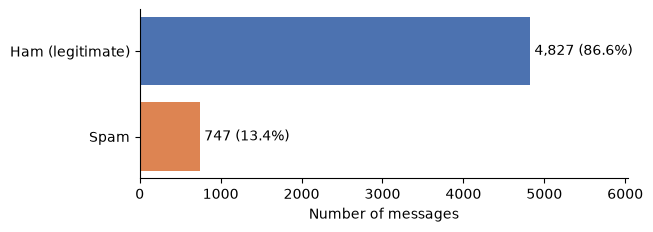

In [6]:
# Figure: class balance
fig, ax = plt.subplots(figsize=(6.3, 2.2))

labels = ["ham", "spam"]
counts = [n_per_label[label] for label in labels]
bars = ax.barh(
    [CLASS_NAMES[label] for label in labels], counts,
    color=[CLASS_COLOURS[label] for label in labels],
)
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
            f"{count:,} ({100 * count / len(sms_raw):.1f}%)", va="center")

ax.invert_yaxis()
ax.set_xlabel("Number of messages")
ax.set_xlim(0, max(counts) * 1.25)
save_figure(fig, "fig_class_balance.png")

2026-09-17 15:30:48 | INFO | Saved fig_data_quality_issues.png


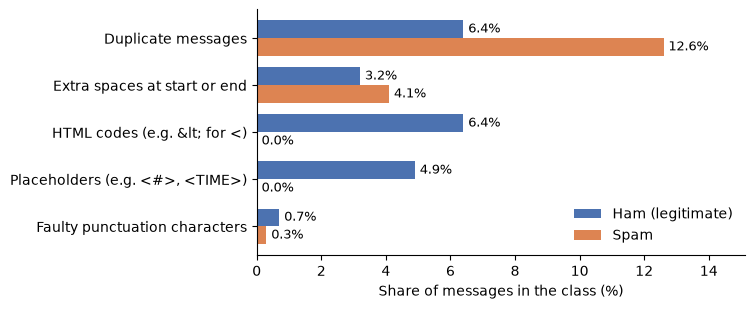

In [7]:
# Figure: data quality issues per class (only checks with findings)
SHORT_LABELS = {
    "Duplicate of an earlier message (same label and text)": "Duplicate messages",
    "Leading or trailing whitespace": "Extra spaces at start or end",
    "HTML-escaped characters (&lt; &gt; &amp;)": "HTML codes (e.g. &lt; for <)",
    "Placeholder instead of original content (e.g. &lt;#&gt;, &lt;TIME&gt;)": "Placeholders (e.g. <#>, <TIME>)",
    "Windows control character instead of punctuation (e.g. \\x92)": "Faulty punctuation characters",
}

issues = quality_table[quality_table["Total"] > 0].copy()
issues["Issue"] = issues["Check"].map(SHORT_LABELS)
if issues["Issue"].isna().any():
    raise KeyError("A check with findings has no short label")

fig, ax = plt.subplots(figsize=(6.3, 3.2))
positions = np.arange(len(issues))
bar_height = 0.38

for offset, label in [(-bar_height / 2, "ham"), (bar_height / 2, "spam")]:
    values = issues[f"% of {label}"]
    ax.barh(positions + offset, values, height=bar_height,
            color=CLASS_COLOURS[label], label=CLASS_NAMES[label])
    for y, value in zip(positions + offset, values):
        ax.text(value + 0.15, y, f"{value:.1f}%", va="center", fontsize=9)

ax.set_yticks(positions, issues["Issue"])
ax.invert_yaxis()
ax.set_xlabel("Share of messages in the class (%)")
ax.set_xlim(0, issues[["% of ham", "% of spam"]].max().max() * 1.2)
ax.legend(frameon=False, loc="lower right")
save_figure(fig, "fig_data_quality_issues.png")

2026-09-17 15:31:02 | INFO | Messages longer than 300 characters (not shown): ham 40, spam 0
2026-09-17 15:31:02 | INFO | Saved fig_message_length.png


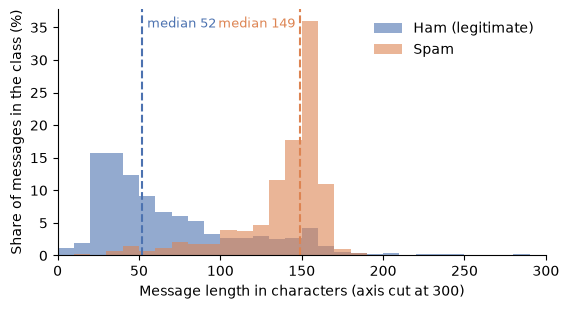

In [8]:
# Figure: message length by class
MAX_CHARACTERS_SHOWN = 300
BIN_WIDTH = 10

n_above_limit = (length_data["characters"] > MAX_CHARACTERS_SHOWN).groupby(length_data["label"]).sum()
logger.info("Messages longer than %d characters (not shown): ham %d, spam %d",
            MAX_CHARACTERS_SHOWN, n_above_limit.get("ham", 0), n_above_limit.get("spam", 0))

fig, ax = plt.subplots(figsize=(6.3, 3.2))
bins = np.arange(0, MAX_CHARACTERS_SHOWN + BIN_WIDTH, BIN_WIDTH)

for label in ["ham", "spam"]:
    lengths = length_data.loc[length_data["label"] == label, "characters"]
    weights = np.full(len(lengths), 100 / len(lengths))  # bars show % of the class
    ax.hist(lengths, bins=bins, weights=weights, alpha=0.6,
            color=CLASS_COLOURS[label], label=CLASS_NAMES[label])

# Median lines are drawn after the bars so the labels sit at the final top of the chart
y_top = ax.get_ylim()[1]
for label, side in [("ham", "left"), ("spam", "right")]:
    median = length_data.loc[length_data["label"] == label, "characters"].median()
    ax.axvline(median, color=CLASS_COLOURS[label], linestyle="--", linewidth=1.5)
    offset = 3 if side == "left" else -3
    ax.text(median + offset, y_top * 0.97, f"median {median:.0f}", ha=side, va="top",
            color=CLASS_COLOURS[label], fontsize=9)

ax.set_xlabel(f"Message length in characters (axis cut at {MAX_CHARACTERS_SHOWN})")
ax.set_ylabel("Share of messages in the class (%)")
ax.set_xlim(0, MAX_CHARACTERS_SHOWN)
ax.legend(frameon=False, loc="upper right")
save_figure(fig, "fig_message_length.png")

## 3. Data preparation

Decisions based on the data quality assessment (2.2):

| Issue | Decision | Reason |
|---|---|---|
| Placeholders (ham only) | Remove | Artefacts of how the ham sources were stored. Kept, they would teach the model a "ham signal" that never appears on the company's channel. The original content (e.g. times, numbers) cannot be restored. |
| HTML escapes (ham only) | Convert back to characters | `&amp;` becomes `&`, as originally written |
| Windows control characters | Replace with normal punctuation | Restores apostrophes, quotation marks and dashes |
| Extra whitespace | Normalise | Formatting noise, no content |
| Duplicates | Remove after cleaning, before splitting | Identical messages in both training and test data would inflate test results |
| Empty messages, conflicting labels | Re-check after cleaning | Cleaning must not create new problems |

Not done here:
- **Lowercasing and word counting** belong to the model and are fitted on training data only (Modelling).
- **Class imbalance** is not changed; it is handled in model evaluation and the choice of risk levels.

Cleaning works message by message and learns nothing from the dataset, so it can be applied before the train/test split without leaking information. The same function can be applied to new incoming messages.

In [9]:
# 3.1 Text cleaning rules
import html
import re

# Same placeholder definition as the quality check in 2.2 (escaped form, e.g. "&lt;#&gt;")
PLACEHOLDER_PATTERN = re.compile(r"&lt;(?:#|[A-Z]+)&gt;")

# Windows punctuation stored as control characters -> plain equivalents
CONTROL_CHARACTER_MAP = str.maketrans({
    "\x91": "'", "\x92": "'",  # single quotation marks
    "\x93": '"', "\x94": '"',  # double quotation marks
    "\x96": "-", "\x97": "-",  # dashes
})


def clean_message(text: str) -> str:
    """Remove data-collection artefacts while keeping the message content."""
    text = PLACEHOLDER_PATTERN.sub(" ", text)     # 1. remove placeholders
    text = html.unescape(text)                    # 2. "&lt;" -> "<", "&amp;" -> "&"
    text = text.translate(CONTROL_CHARACTER_MAP)  # 3. repair punctuation characters
    return re.sub(r"\s+", " ", text).strip()      # 4. normalise whitespace


# --- Show one before/after example per artefact type ------------------------
example_patterns = {
    "Placeholder": r"&lt;TIME&gt;",
    "HTML escape": r"&amp;",
    "Control character": r"[\x80-\x9f]",
}
examples = []
for artefact, pattern in example_patterns.items():
    first_match = sms_raw["message"].str.contains(pattern, regex=True).idxmax()
    before = sms_raw.loc[first_match, "message"]
    examples.append({"Artefact": artefact, "Before": before, "After": clean_message(before)})
cleaning_examples = pd.DataFrame(examples)
cleaning_examples

,Artefact,Before,After
0,Placeholder,Appt is at &lt;TIME&gt; am. Not my fault u don...,Appt is at am. Not my fault u don't listen. I ...
1,HTML escape,"I'm back &amp; we're packing the car now, I'll...","I'm back & we're packing the car now, I'll let..."
2,Control character,Fine if thats the way u feel. Thats the way ...,Fine if that's the way u feel. That's the way ...


In [10]:
# 3.2 Apply the preparation steps
def class_counts(frame: pd.DataFrame, step: str) -> dict:
    """Record the number of messages per class after a preparation step."""
    counts = frame["label"].value_counts()
    ham, spam = int(counts.get("ham", 0)), int(counts.get("spam", 0))
    return {"Step": step, "Ham": ham, "Spam": spam, "Total": ham + spam,
            "Spam share (%)": round(100 * spam / (ham + spam), 1)}


preparation_log = [class_counts(sms_raw, "Raw data")]

# --- Clean the text ---------------------------------------------------------
sms_clean = sms_raw.copy()
sms_clean["message"] = sms_raw["message"].map(clean_message)
changed = sms_clean["message"] != sms_raw["message"]
logger.info("Messages changed by cleaning: %d (ham %d, spam %d)", changed.sum(),
            (changed & (sms_clean["label"] == "ham")).sum(),
            (changed & (sms_clean["label"] == "spam")).sum())

# --- Remove messages that are empty after cleaning --------------------------
empty = sms_clean["message"] == ""
sms_clean = sms_clean[~empty]
logger.info("Messages empty after cleaning (removed): %d", empty.sum())
preparation_log.append(class_counts(sms_clean, "After text cleaning"))

# --- Check for conflicting labels after cleaning ----------------------------
n_conflicts = int((sms_clean.groupby("message")["label"].transform("nunique") > 1).sum())
logger.info("Messages with conflicting labels after cleaning: %d", n_conflicts)
if n_conflicts:
    raise ValueError("Identical cleaned texts carry different labels; resolve before continuing")

# --- Remove duplicates (keep the first occurrence) --------------------------
n_before = len(sms_clean)
n_raw_duplicates = int(sms_raw.duplicated().sum())
sms_clean = sms_clean.drop_duplicates(subset=["label", "message"], keep="first")
n_removed = n_before - len(sms_clean)
logger.info("Duplicates removed: %d (exact duplicates in raw data: %d; additional after cleaning: %d)",
            n_removed, n_raw_duplicates, n_removed - n_raw_duplicates)
preparation_log.append(class_counts(sms_clean, "After removing duplicates"))

# --- Encode the target (spam = positive class) ------------------------------
sms_clean = sms_clean.reset_index(drop=True)
sms_clean["is_spam"] = (sms_clean["label"] == "spam").astype(int)

# --- Verify that no artefacts remain ----------------------------------------
remaining = {
    "placeholders": sms_clean["message"].str.contains(r"<(?:#|DECIMAL|TIME|URL|EMAIL)>", regex=True),
    "HTML escapes": sms_clean["message"].str.contains(r"&(?:lt|gt|amp);", regex=True),
    "control characters": sms_clean["message"].str.contains(r"[\x80-\x9f]", regex=True),
}
for artefact, flagged in remaining.items():
    logger.info("Remaining %-18s %d", artefact + ":", int(flagged.sum()))
    if flagged.any():
        raise ValueError(f"Cleaning incomplete: {artefact} remain")

preparation_table = pd.DataFrame(preparation_log)
preparation_table.to_csv(TABLES_DIR / "tab_data_preparation.csv", index=False)
logger.info("Prepared data: %d messages (%d spam). Saved tab_data_preparation.csv",
            len(sms_clean), sms_clean["is_spam"].sum())
preparation_table

2026-09-17 20:14:52 | INFO | Messages changed by cleaning: 553 (ham 520, spam 33)
2026-09-17 20:14:52 | INFO | Messages empty after cleaning (removed): 0
2026-09-17 20:14:52 | INFO | Messages with conflicting labels after cleaning: 0
2026-09-17 20:14:52 | INFO | Duplicates removed: 414 (exact duplicates in raw data: 403; additional after cleaning: 11)
2026-09-17 20:14:52 | INFO | Remaining placeholders:      0
2026-09-17 20:14:52 | INFO | Remaining HTML escapes:      0
2026-09-17 20:14:52 | INFO | Remaining control characters: 0
2026-09-17 20:14:52 | INFO | Prepared data: 5160 messages (642 spam). Saved tab_data_preparation.csv


,Step,Ham,Spam,Total,Spam share (%)
0,Raw data,4827,747,5574,13.4
1,After text cleaning,4827,747,5574,13.4
2,After removing duplicates,4518,642,5160,12.4


## 4. Modelling

### 4.1 Test design

- **Split:** 80% training, 20% test, stratified so both sets keep the 12.4% spam share. Fixed seed (42) makes the split reproducible.
- **Model selection:** 5-fold stratified cross-validation on the **training set only**. The test set is used once, for the final evaluation.
- **Metrics:**
  - *Average precision* (area under the precision-recall curve) is the main criterion. It focuses on the spam class, which matters here because only 12.4% of messages are spam.
  - *ROC AUC* is reported as a second threshold-independent measure.
  - *F1 at threshold 0.5* is reported for reference only. The operating threshold is a business decision and is set later through the risk levels, so a model must not be judged by its default threshold alone.

### 4.2 Candidate models

Messages are short and the filter must be fast and explainable, so word-based models are used: each message becomes a vector of word counts (CountVectorizer) or weighted word frequencies (TF-IDF), combined with Naive Bayes or Logistic Regression. A model that always predicts "ham" serves as the reference point, since with 12.4% spam it already reaches 87.6% accuracy.

Text is lowercased and tokenised inside the pipeline, so the vocabulary is learned from the training folds only and no information leaks from the test data.

In [12]:
# 4.1 Test design: stratified train/test split
from sklearn.model_selection import train_test_split

TEST_SIZE = 0.2

X = sms_clean["message"]
y = sms_clean["is_spam"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

for name, target in [("Training", y_train), ("Test", y_test)]:
    logger.info("%-8s set: %d messages, %d spam (%.1f%%)",
                name, len(target), target.sum(), 100 * target.mean())

# The test set must stay unseen: no message may appear in both sets
overlap = set(X_train) & set(X_test)
if overlap:
    raise ValueError(f"{len(overlap)} messages appear in both training and test set")
logger.info("No message appears in both sets")

2026-09-17 20:27:17 | INFO | Training set: 4128 messages, 514 spam (12.5%)
2026-09-17 20:27:17 | INFO | Test     set: 1032 messages, 128 spam (12.4%)
2026-09-17 20:27:17 | INFO | No message appears in both sets


In [13]:
# 4.2 Candidate models compared by cross-validation on the training set
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

CV_FOLDS = 5
METRIC_NAMES = {
    "average_precision": "Average precision",  # area under the precision-recall curve
    "roc_auc": "ROC AUC",
    "f1": "F1 at threshold 0.5",
}

candidates = {
    "Always ham (baseline)": Pipeline([
        ("features", CountVectorizer()),
        ("model", DummyClassifier(strategy="most_frequent")),
    ]),
    "Word counts + Naive Bayes": Pipeline([
        ("features", CountVectorizer()),
        ("model", MultinomialNB()),
    ]),
    "TF-IDF + Naive Bayes": Pipeline([
        ("features", TfidfVectorizer()),
        ("model", MultinomialNB()),
    ]),
    "Word counts + Logistic Regression": Pipeline([
        ("features", CountVectorizer()),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    "TF-IDF + Logistic Regression": Pipeline([
        ("features", TfidfVectorizer()),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
}

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
comparison_rows = []
for name, pipeline in candidates.items():
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=list(METRIC_NAMES))
    row = {"Model": name}
    for metric, display_name in METRIC_NAMES.items():
        row[display_name] = round(scores[f"test_{metric}"].mean(), 3)
        row[f"{display_name} (sd)"] = round(scores[f"test_{metric}"].std(), 3)
    comparison_rows.append(row)
    logger.info("%-34s AP %.3f | ROC AUC %.3f | F1 %.3f", name,
                row["Average precision"], row["ROC AUC"], row["F1 at threshold 0.5"])

comparison_table = pd.DataFrame(comparison_rows)
comparison_table.to_csv(TABLES_DIR / "tab_model_comparison.csv", index=False)
logger.info("Saved tab_model_comparison.csv")
comparison_table

2026-09-17 20:27:37 | INFO | Always ham (baseline)              AP 0.125 | ROC AUC 0.500 | F1 0.000
2026-09-17 20:27:37 | INFO | Word counts + Naive Bayes          AP 0.954 | ROC AUC 0.972 | F1 0.936
2026-09-17 20:27:38 | INFO | TF-IDF + Naive Bayes               AP 0.943 | ROC AUC 0.976 | F1 0.739
2026-09-17 20:27:38 | INFO | Word counts + Logistic Regression  AP 0.955 | ROC AUC 0.980 | F1 0.900
2026-09-17 20:27:38 | INFO | TF-IDF + Logistic Regression       AP 0.960 | ROC AUC 0.986 | F1 0.834
2026-09-17 20:27:38 | INFO | Saved tab_model_comparison.csv


,Model,Average precision,Average precision (sd),ROC AUC,ROC AUC (sd),F1 at threshold 0.5,F1 at threshold 0.5 (sd)
0,Always ham (baseline),0.125,0.000,0.500,0.000,0.000,0.000
1,Word counts + Naive Bayes,0.954,0.018,0.972,0.015,0.936,0.016
2,TF-IDF + Naive Bayes,0.943,0.017,0.976,0.011,0.739,0.038
3,Word counts + Logistic Regression,0.955,0.018,0.980,0.008,0.900,0.014
4,TF-IDF + Logistic Regression,0.960,0.014,0.986,0.004,0.834,0.031


### 4.3 Selected model

**TF-IDF + Logistic Regression.** It reached the highest average precision (0.960) and ROC AUC (0.986) with the smallest variation across folds. The differences to the other candidates are small, so the choice also rests on two practical reasons: the model returns a spam score between 0 and 1, which the adjustable risk levels need, and its coefficients show which words drive a decision, which the error analysis needs.

## 5. Evaluation on the test set

The model is now trained on the full training set and applied once to the 1,032 held-out test messages. The default threshold of 0.5 is only a starting point; Section 6 sets the thresholds that implement the risk levels.

In [14]:
# 4.3 Train the selected model on the full training set
from sklearn.metrics import (accuracy_score, average_precision_score, confusion_matrix,
                             f1_score, precision_score, recall_score, roc_auc_score)

spam_filter = Pipeline([
    ("features", TfidfVectorizer()),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
spam_filter.fit(X_train, y_train)
logger.info("Model trained on %d messages; vocabulary: %d words",
            len(X_train), len(spam_filter.named_steps["features"].vocabulary_))

# Spam score of each test message (probability between 0 and 1)
test_scores = spam_filter.predict_proba(X_test)[:, 1]

2026-09-17 20:32:05 | INFO | Model trained on 4128 messages; vocabulary: 7671 words


In [15]:
# 5. Evaluation on the test set
DEFAULT_THRESHOLD = 0.5
predicted_spam = (test_scores >= DEFAULT_THRESHOLD).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, predicted_spam).ravel()
test_metrics = {
    "Average precision": average_precision_score(y_test, test_scores),
    "ROC AUC": roc_auc_score(y_test, test_scores),
    "Accuracy at 0.5": accuracy_score(y_test, predicted_spam),
    "Precision at 0.5": precision_score(y_test, predicted_spam),
    "Recall at 0.5": recall_score(y_test, predicted_spam),
    "F1 at 0.5": f1_score(y_test, predicted_spam),
}
metrics_table = pd.DataFrame({"Metric": list(test_metrics),
                              "Value": [round(value, 3) for value in test_metrics.values()]})
metrics_table.to_csv(TABLES_DIR / "tab_test_metrics.csv", index=False)

for metric, value in test_metrics.items():
    logger.info("%-18s %.3f", metric + ":", value)
logger.info("Confusion matrix at threshold %.2f: TN %d, FP %d, FN %d, TP %d",
            DEFAULT_THRESHOLD, tn, fp, fn, tp)
logger.info("Spam reaching the channel: %d of %d | legitimate messages held back: %d of %d",
            fn, fn + tp, fp, fp + tn)
metrics_table

2026-09-17 20:32:18 | INFO | Average precision: 0.961
2026-09-17 20:32:18 | INFO | ROC AUC:           0.993
2026-09-17 20:32:18 | INFO | Accuracy at 0.5:   0.960
2026-09-17 20:32:18 | INFO | Precision at 0.5:  0.968
2026-09-17 20:32:18 | INFO | Recall at 0.5:     0.703
2026-09-17 20:32:18 | INFO | F1 at 0.5:         0.814
2026-09-17 20:32:18 | INFO | Confusion matrix at threshold 0.50: TN 901, FP 3, FN 38, TP 90
2026-09-17 20:32:18 | INFO | Spam reaching the channel: 38 of 128 | legitimate messages held back: 3 of 904


,Metric,Value
0,Average precision,0.961
1,ROC AUC,0.993
2,Accuracy at 0.5,0.960
3,Precision at 0.5,0.968
4,Recall at 0.5,0.703
5,F1 at 0.5,0.814


2026-09-17 20:32:43 | INFO | Saved fig_test_curves.png


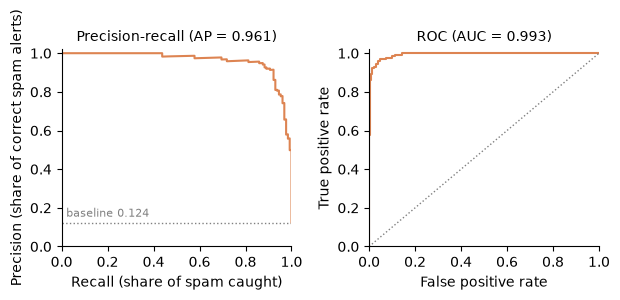

In [16]:
# Figure: precision-recall and ROC curve on the test set
from sklearn.metrics import precision_recall_curve, roc_curve

precision, recall, _ = precision_recall_curve(y_test, test_scores)
false_positive_rate, true_positive_rate, _ = roc_curve(y_test, test_scores)
spam_share = y_test.mean()

fig, axes = plt.subplots(1, 2, figsize=(6.3, 2.9))

axes[0].plot(recall, precision, color=CLASS_COLOURS["spam"])
axes[0].axhline(spam_share, color="grey", linestyle=":", linewidth=1)
axes[0].text(0.02, spam_share + 0.03, f"baseline {spam_share:.3f}", color="grey", fontsize=8)
axes[0].set_xlabel("Recall (share of spam caught)")
axes[0].set_ylabel("Precision (share of correct spam alerts)")
axes[0].set_title(f"Precision-recall (AP = {test_metrics['Average precision']:.3f})", fontsize=10)

axes[1].plot(false_positive_rate, true_positive_rate, color=CLASS_COLOURS["spam"])
axes[1].plot([0, 1], [0, 1], color="grey", linestyle=":", linewidth=1)
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].set_title(f"ROC (AUC = {test_metrics['ROC AUC']:.3f})", fontsize=10)

for ax in axes:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
fig.tight_layout()
save_figure(fig, "fig_test_curves.png")

## 6. Adjustable risk levels

The model outputs a spam score between 0 and 1. A risk level is a threshold on that score: messages scoring below it pass the filter and are displayed immediately; messages at or above it go to the review folder.

Each level is defined by how much spam the service team wants the filter to catch:

| Risk level | Meaning | Target |
|---|---|---|
| Low risk | Very restrictive; almost nothing unwanted should reach the channel | catch at least 98% of spam |
| Medium risk | Balanced | catch at least 90% of spam |
| High risk | Not restrictive; only obvious spam is held back | catch at least 80% of spam |

Thresholds are derived from **out-of-fold scores on the training set**: every training message is scored by a model that was not trained on it. This keeps the test set untouched, so the test results below are an honest estimate of what each level does in production.

In [17]:
# 6.1 Risk levels: thresholds chosen on the training data
from sklearn.model_selection import cross_val_predict

RECALL_TARGETS = {"Low risk (very restrictive)": 0.98,
                  "Medium risk": 0.90,
                  "High risk (not restrictive)": 0.80}

# Out-of-fold scores: every training message is scored by a model that did not see it
training_scores = cross_val_predict(spam_filter, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
train_precision, train_recall, train_thresholds = precision_recall_curve(y_train, training_scores)


def threshold_for_recall(target_recall: float) -> float:
    """Highest threshold that still catches at least the target share of spam."""
    reachable = train_recall[:-1] >= target_recall  # the last curve point has no threshold
    return float(train_thresholds[reachable].max())


risk_thresholds = {level: threshold_for_recall(target) for level, target in RECALL_TARGETS.items()}
for level, threshold in risk_thresholds.items():
    logger.info("%-28s target recall %.2f -> threshold %.3f",
                level, RECALL_TARGETS[level], threshold)

2026-09-17 20:38:39 | INFO | Low risk (very restrictive)  target recall 0.98 -> threshold 0.073
2026-09-17 20:38:39 | INFO | Medium risk                  target recall 0.90 -> threshold 0.245
2026-09-17 20:38:39 | INFO | High risk (not restrictive)  target recall 0.80 -> threshold 0.395


In [18]:
# 6.2 What each risk level does on the test set
risk_rows = []
for level, threshold in risk_thresholds.items():
    flagged = (test_scores >= threshold).astype(int)
    tn_l, fp_l, fn_l, tp_l = confusion_matrix(y_test, flagged).ravel()
    risk_rows.append({
        "Risk level": level,
        "Threshold": round(threshold, 3),
        "Spam caught": f"{tp_l} of {tp_l + fn_l}",
        "Spam displayed": fn_l,
        "Legitimate held back": f"{fp_l} of {tn_l + fp_l}",
        "Recall (%)": round(100 * tp_l / (tp_l + fn_l), 1),
        "Precision (%)": round(100 * tp_l / (tp_l + fp_l), 1),
        "To review folder per 1,000 messages": round(1000 * (tp_l + fp_l) / len(y_test)),
    })

risk_table = pd.DataFrame(risk_rows)
risk_table.to_csv(TABLES_DIR / "tab_risk_levels.csv", index=False)
logger.info("Saved tab_risk_levels.csv")
risk_table

2026-09-17 20:38:53 | INFO | Saved tab_risk_levels.csv


,Risk level,Threshold,Spam caught,Spam displayed,Legitimate held back,Recall (%),Precision (%),"To review folder per 1,000 messages"
0,Low risk (very restrictive),0.073,128 of 128,0,171 of 904,100.0,42.8,290
1,Medium risk,0.245,118 of 128,10,11 of 904,92.2,91.5,125
2,High risk (not restrictive),0.395,101 of 128,27,4 of 904,78.9,96.2,102


2026-09-17 20:39:27 | INFO | Saved fig_risk_levels.png


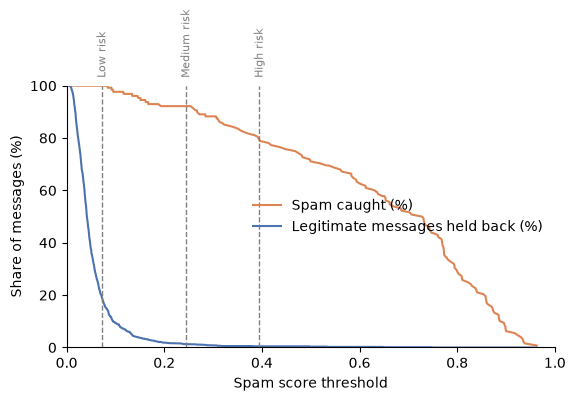

In [19]:
# Figure: effect of the threshold, with the three risk levels marked
test_precision, test_recall, test_thresholds = precision_recall_curve(y_test, test_scores)
ham_held_back = [(test_scores[y_test == 0] >= t).mean() * 100 for t in test_thresholds]

fig, ax = plt.subplots(figsize=(6.3, 3.4))
ax.plot(test_thresholds, test_recall[:-1] * 100, color=CLASS_COLOURS["spam"], label="Spam caught (%)")
ax.plot(test_thresholds, ham_held_back, color=CLASS_COLOURS["ham"], label="Legitimate messages held back (%)")

for level, threshold in risk_thresholds.items():
    ax.axvline(threshold, color="grey", linestyle="--", linewidth=1)
    ax.text(threshold, 103, level.split(" (")[0], rotation=90, fontsize=8,
            va="bottom", ha="center", color="grey")

ax.set_xlabel("Spam score threshold")
ax.set_ylabel("Share of messages (%)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 100)
ax.legend(frameon=False, loc="center right")
save_figure(fig, "fig_risk_levels.png")